## Data preparation

Plate reader data is loaded using pr.load_platereader_data, which parses the raw instrument output and merges the platemap to annotate each well with its construct identity.



In [1]:
from cdk.analysis.cytosol import platereader as pr
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
pr.plot_setup()

In [2]:
data, platemap = pr.load_platereader_data(
    data_file="20251030-113717-cytation5-pure-timecourse-TO1Biotin-mScarlet--biotek-cdk-2.txt",
    platemap_file="20251030_TO1Biotin_mScarlet_platemap.tsv",
)

# Background subtraction — remove negative control signal from all wells at each timepoint
neg_mean = data[data["Name"] == "Negative"].groupby(["Time", "Read"])["Data"].mean()
data["Data"] = data.apply(
    lambda row: row["Data"] - neg_mean.loc[(row["Time"], row["Read"])], axis=1
)
data["Time (hours)"] = data["Time"].dt.total_seconds() / 3600

data.to_csv("20251030_MangoTO1_mScarlet_data_background_sbtrk.csv", index=True)
print(f"Saved background-subtracted data: {len(data)} rows")

Saved background-subtracted data: 1980 rows


## Timecourse analysis

### Full timecourse
The full timecourse plots show the raw fluorescence data for each construct across the entire 
experiment duration, excluding the negative control. Each trace represents the mean across three 
replicate wells with shaded regions indicating 95% confidence interval. The aptamer reporter 
(transcription) and mScarlet (translation) are plotted separately.

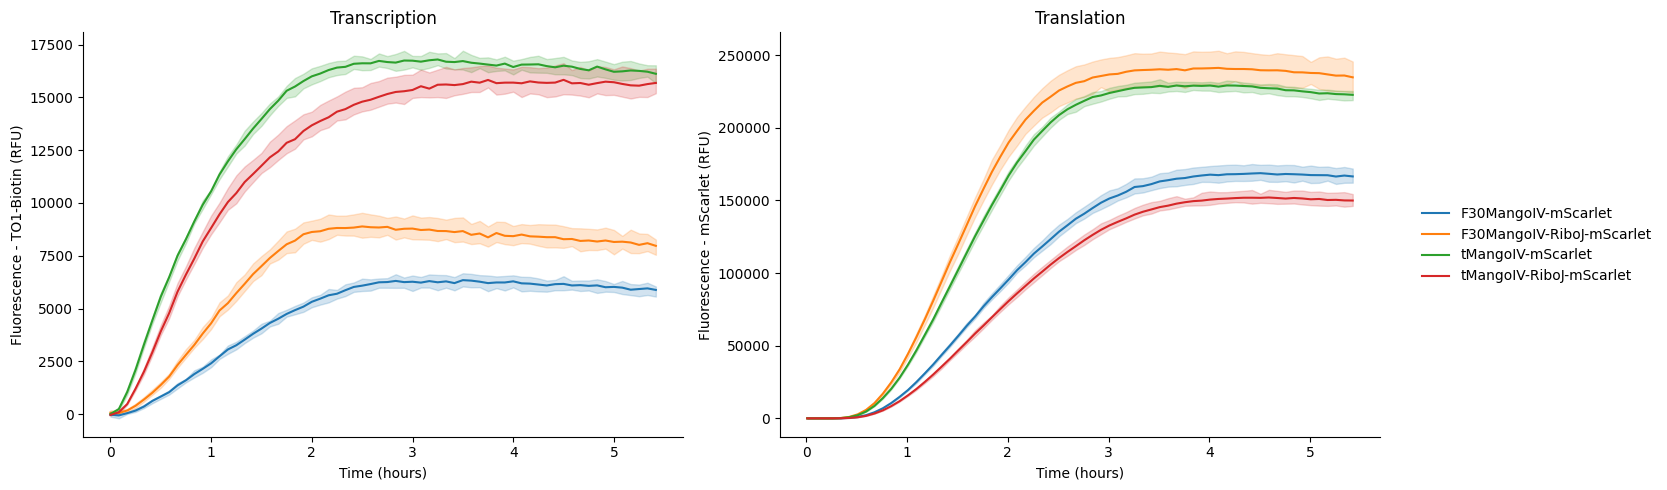

In [16]:
data["Time (hours)"] = data["Time"].dt.total_seconds() / 3600

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, read, ylabel in [
    (axes[0], "TO1-Biotin", "Fluorescence - TO1-Biotin (RFU)"),
    (axes[1], "mScarlet", "Fluorescence - mScarlet (RFU)")
]:
    subset = data[(data["Read"] == read) & (data["Name"] != "Negative")]
    sns.lineplot(data=subset, x="Time (hours)", y="Data", hue="Name", ax=ax)
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel(ylabel)
    ax.get_legend().remove()

axes[0].set_title("Transcription")
axes[1].set_title("Translation")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, bbox_to_anchor=(1.01, 0.5), loc="center left", frameon=False)
sns.despine()
plt.tight_layout()
plt.savefig("./figures/MangoTO1_mScarlet_full_timecourse_Background_sbtrkt.png", dpi=600, bbox_inches="tight")
plt.show()

### First hour
The first-hour plots show the early period of the experiment, split by aptamer variant to allow 
direct comparison of RiboJ and non-RiboJ constructs. Each trace represents the mean across three 
replicate wells with shaded regions indicating 95% confidence interval.

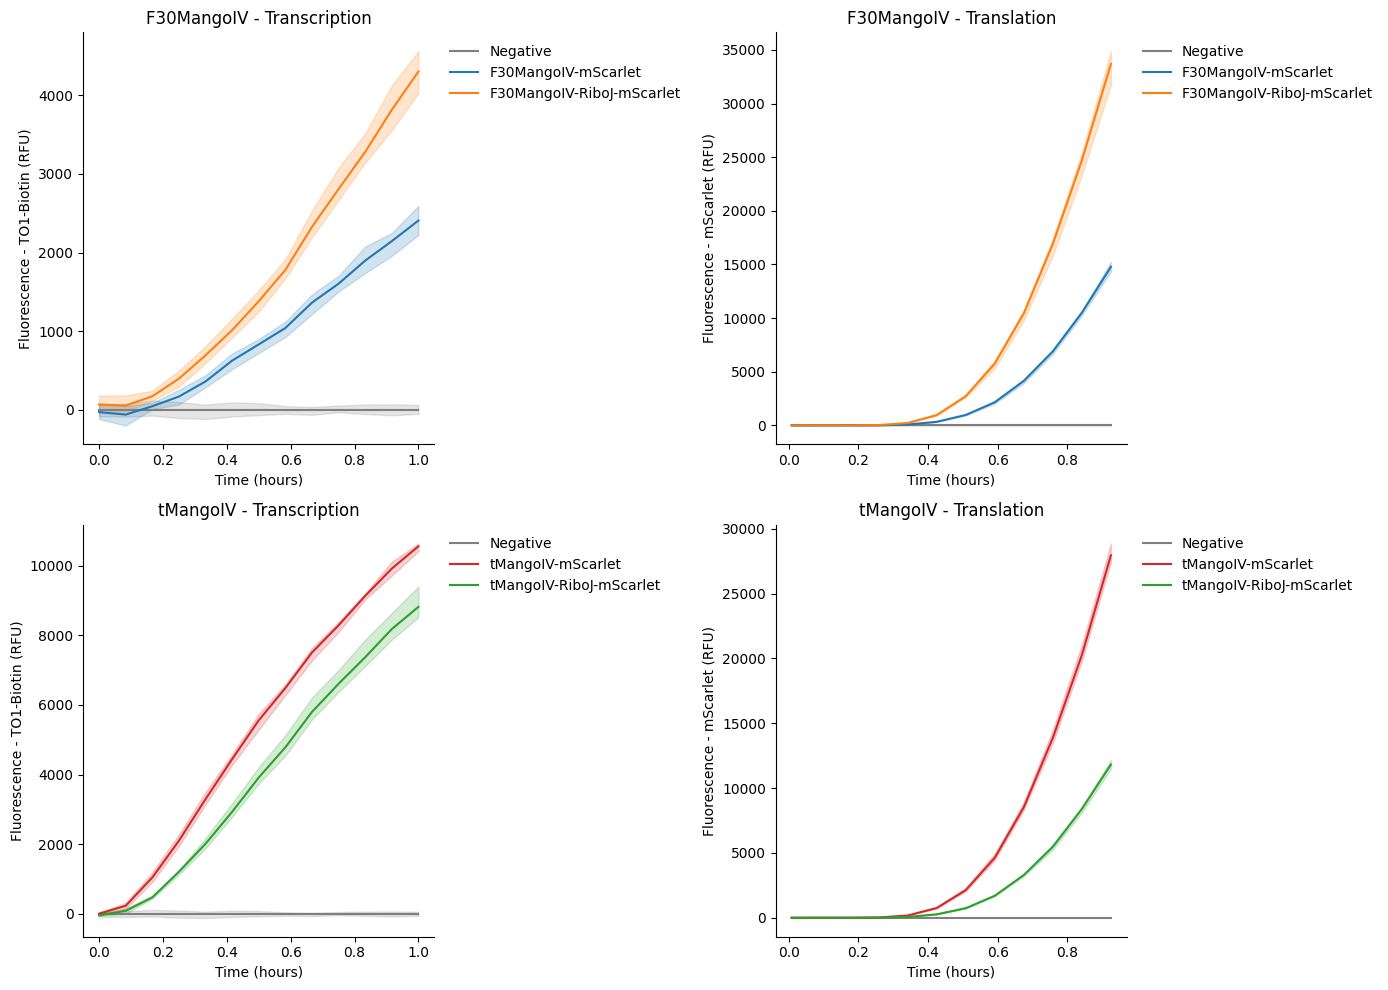

In [4]:
mango_colours = {
    "F30MangoIV-mScarlet": "tab:blue",
    "F30MangoIV-RiboJ-mScarlet": "tab:orange",
    "tMangoIV-RiboJ-mScarlet": "tab:green",
    "tMangoIV-mScarlet": "tab:red",
    "Negative": "tab:grey"
}
variants = {"F30MangoIV": 0, "tMangoIV": 1}
one_hour = pd.Timedelta("1 hour")

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for variant, row in variants.items():
    names = list(data[data["Name"].str.contains(variant)]["Name"].unique()) + ["Negative"]
    for col, read, ylabel in [(0, "TO1-Biotin", "Fluorescence - TO1-Biotin (RFU)"),
                               (1, "mScarlet", "Fluorescence - mScarlet (RFU)")]:
        subset = data[
            (data["Read"] == read) &
            (data["Name"].isin(names)) &
            (data["Time"] <= one_hour)
        ]
        sns.lineplot(data=subset, x="Time (hours)", y="Data", hue="Name",
                     palette={n: mango_colours[n] for n in names},
                     ax=axes[row, col])
        axes[row, col].set_xlabel("Time (hours)")
        axes[row, col].set_ylabel(ylabel)
        axes[row, col].get_legend().remove()
    axes[row, 0].set_title(f"{variant} - Transcription")
    axes[row, 1].set_title(f"{variant} - Translation")
    for col in [0, 1]:
        handles, labels = axes[row, col].get_legend_handles_labels()
        axes[row, col].legend(handles, labels, frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")

sns.despine()
plt.tight_layout()
plt.savefig("./figures/Mango_mScarlet_first_hour_Background_sbtrkt.png", dpi=600, bbox_inches="tight")
plt.show()

## Kinetic analysis

Sigmoid drift curves are fitted and visualised per construct using `pr.plot_kinetics`, grouped 
by name and read type separately for the transcription reporter and mScarlet.

Lag times are then extracted per replicate well individually using `pr.kinetic_analysis_per_well`. 
Note that `pr.kinetic_analysis` cannot be called directly on the full dataset here as the tMangoIV 
TO1-Biotin curves have no observable lag phase, causing the sigmoid fitter to extrapolate to -inf 
lag times which results in an overflow error. Read types are therefore processed separately to 
allow negative lag times to be clipped before this occurs. Lag times for the transcription reporter 
and mScarlet are plotted side by side per construct with error bars representing standard deviation 
across three replicate wells. The translation initiation delay is calculated as the difference 
between the mScarlet lag time and the aptamer lag time.

PROVIDING AVERAGED KINETICS
PROVIDING AVERAGED KINETICS


Text(0.5, 1.02, 'TO1 biotin — Transcription')

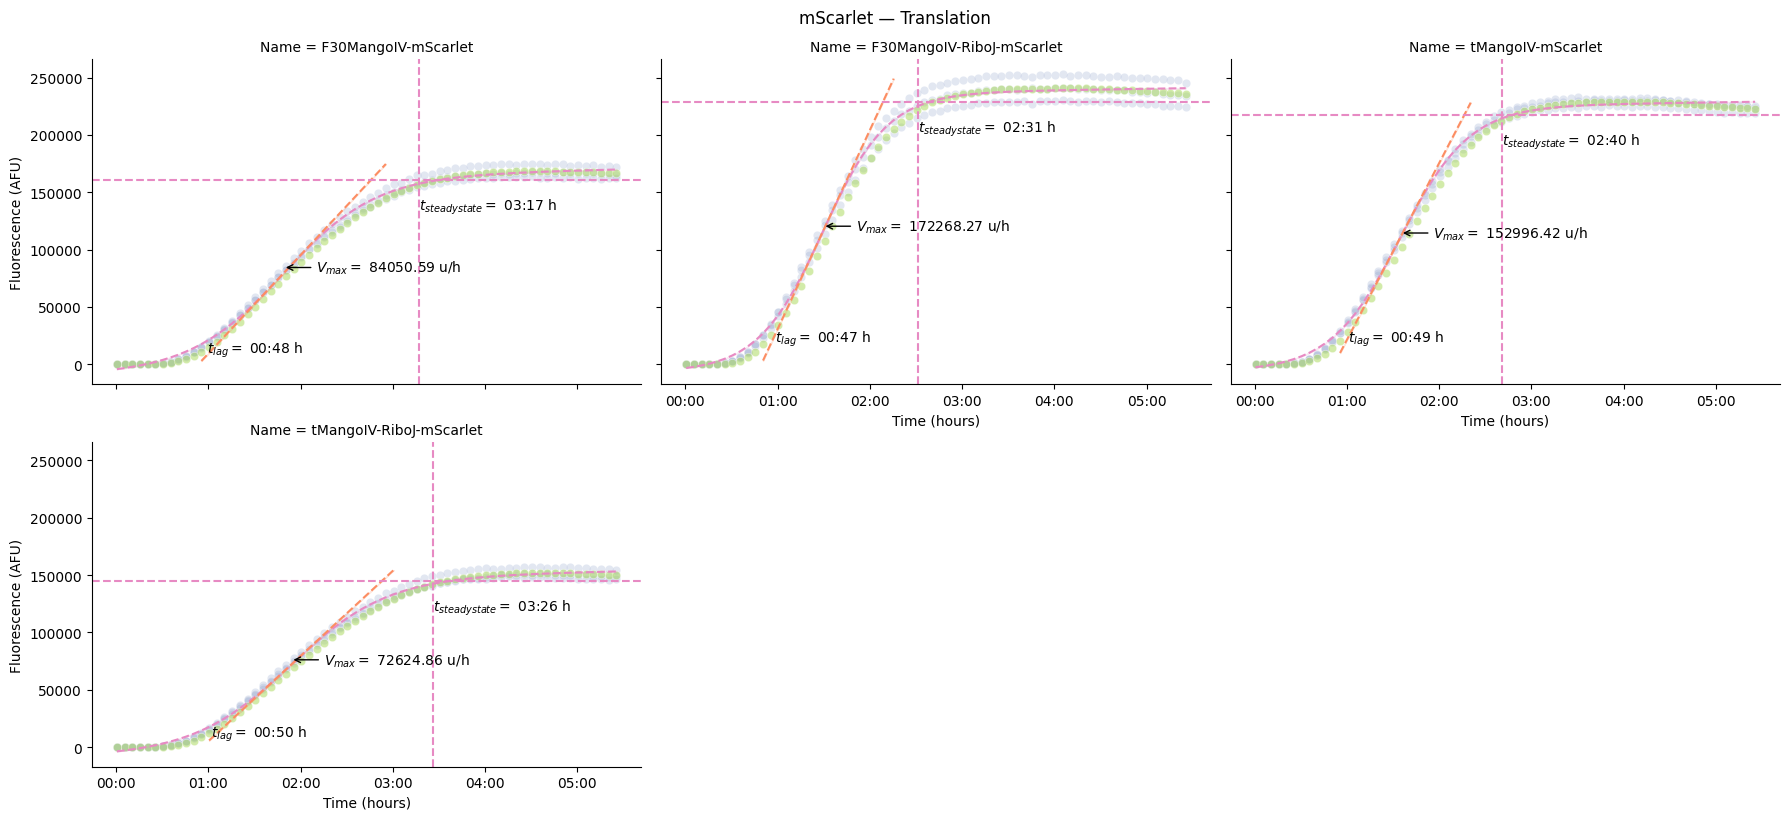

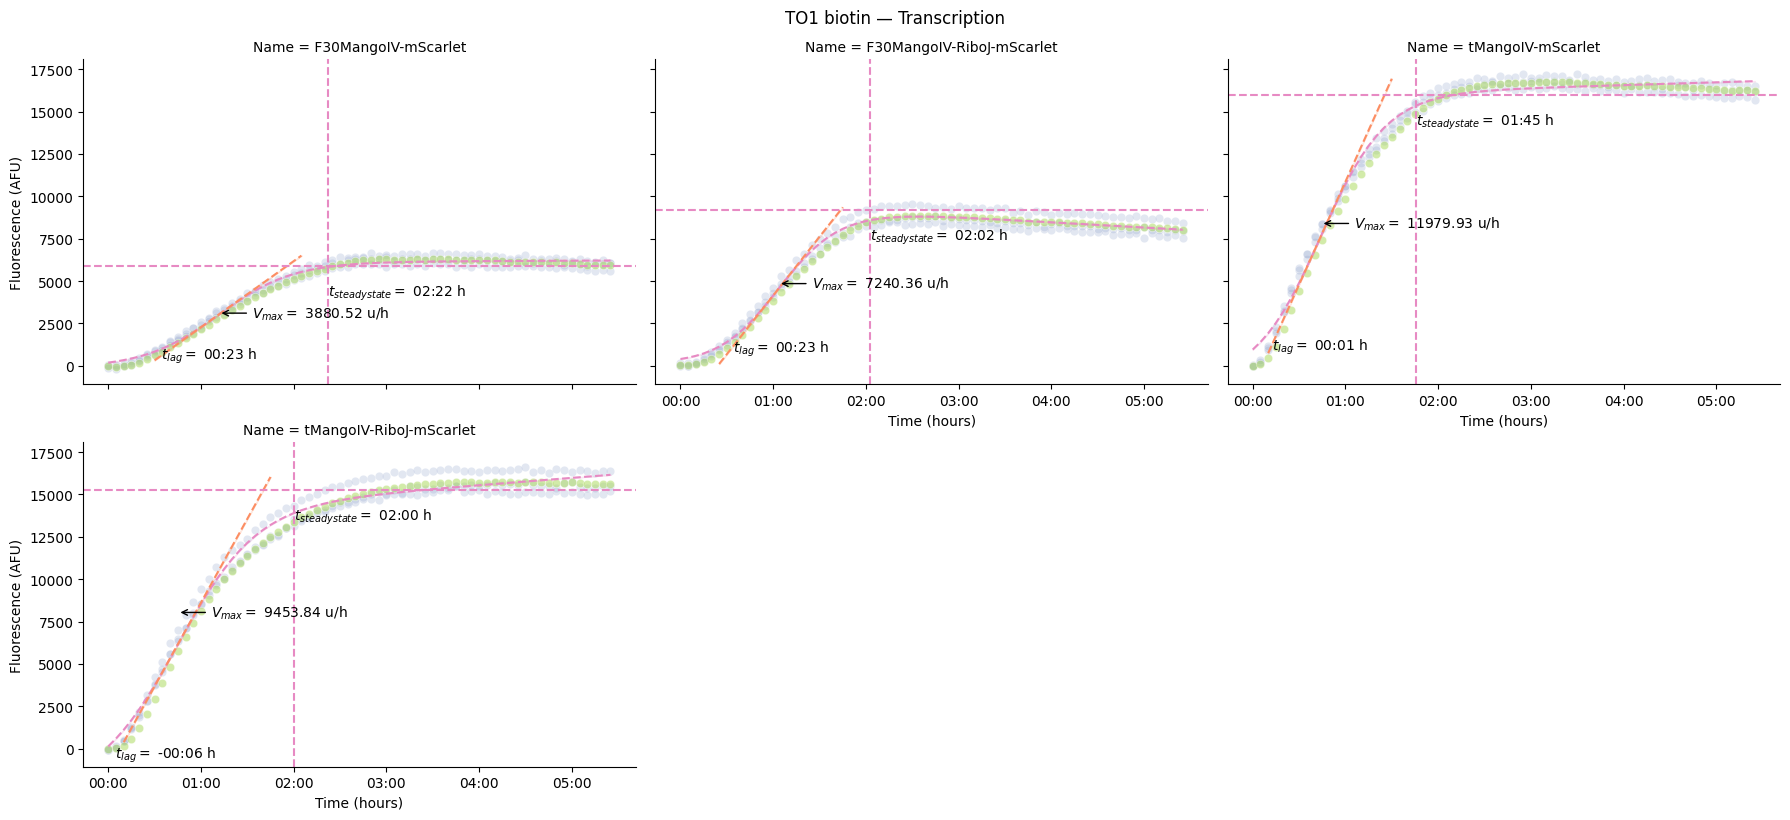

In [15]:
mScarlet_kinetics_plot, _ = pr.plot_kinetics(data[(data["Name"] != "Negative") & (data["Read"] == "mScarlet")], group_by=["Name", "Read"])

mScarlet_kinetics_plot.fig.suptitle("mScarlet — Translation", y=1.02)
#mScarlet_kinetics_plot.fig.savefig("./figures/Broccoli_mScarlet_kinetics.png", dpi=600, bbox_inches="tight")

TO1_biotin_kinetics_plot, _ = pr.plot_kinetics(data[(data["Name"] != "Negative") & (data["Read"] == "TO1-Biotin")], group_by=["Name", "Read"])

TO1_biotin_kinetics_plot.fig.suptitle("TO1 biotin — Transcription", y=1.02)
#TO1_biotin_kinetics_plot.fig.savefig("./figures/Broccoli_mScarlet_kinetics.png", dpi=600, bbox_inches="tight")

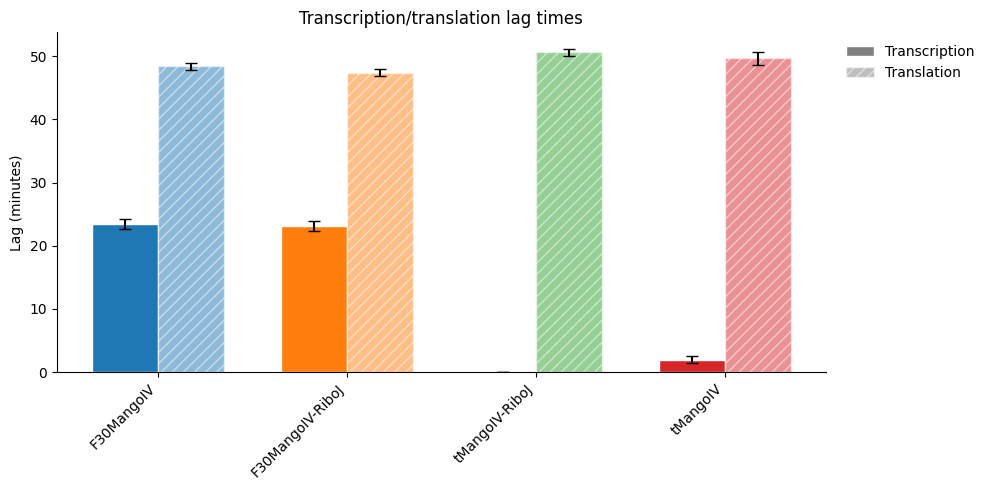

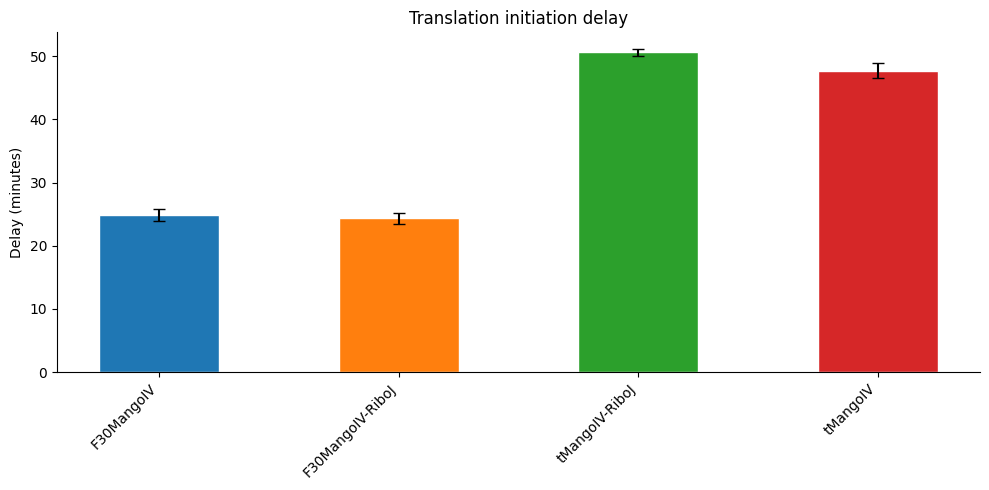

In [13]:
# NOTE: Unlike the Broccoli dataset where pr.kinetic_analysis() could be called directly on
# the full dataset, here we must call kinetic_analysis_per_well manually for each read type
# separately. This is because tMangoIV TO1-Biotin curves have no observable lag phase, causing
# the sigmoid fitter to extrapolate to -inf lag times. When pr.kinetic_analysis() attempts to
# convert -inf to a pd.Timedelta it throws an OutOfBoundsTimedelta overflow error and crashes.
# By processing each read type separately we can intercept and clip the negative values before
# they cause a crash.

# Per-well kinetics for mScarlet
per_well_mScarlet = (
    data[(data["Name"] != "Negative") & (data["Read"] == "mScarlet")]
    .groupby(["Name", "Read", "Well"])
    .apply(pr.kinetic_analysis_per_well)
)
# Per-well kinetics for TO1-Biotin
per_well_TO1 = (
    data[(data["Name"] != "Negative") & (data["Read"] == "TO1-Biotin")]
    .groupby(["Name", "Read", "Well"])
    .apply(pr.kinetic_analysis_per_well)
)
# Extract lag times in minutes
mScarlet_lag = per_well_mScarlet["Lag"]["Time"].dt.total_seconds() / 60
TO1_lag = per_well_TO1["Lag"]["Time"].dt.total_seconds() / 60

# NOTE: tMangoIV TO1-Biotin signal rises immediately from t=0 with no observable lag phase.
# The sigmoid fitter extrapolates to negative lag times for these constructs, which is not
# biologically meaningful. We therefore clip negative values to 0, treating transcription
# onset as t=0 for tMangoIV constructs.
#
# NOTE: F30MangoIV TO1-Biotin curves show early noise (a small dip at ~5-15 min) but the
# sigmoid fitter handles this robustly — visual inspection of the kinetics plots confirms
# the fitted lag times of ~8-16 min are accurate and not artefactual, as the fitted curve
# tracks the data well beyond the noisy early timepoints.
TO1_lag = TO1_lag.clip(lower=0)

# Means and stds
lag_mean = mScarlet_lag.groupby("Name").mean()
lag_std = mScarlet_lag.groupby("Name").std()
TO1_lag_mean = TO1_lag.groupby("Name").mean()
TO1_lag_std = TO1_lag.groupby("Name").std()

# Translation initiation delay
delay_mean = lag_mean - TO1_lag_mean
delay_std = (lag_std**2 + TO1_lag_std**2)**0.5

# Save copies before plotting code can overwrite these variables
lag_mean_saved = lag_mean.copy()
lag_std_saved = lag_std.copy()
TO1_lag_mean_saved = TO1_lag_mean.copy()
TO1_lag_std_saved = TO1_lag_std.copy()

# Transcription/translation lag times
from matplotlib.patches import Patch
mango_colours_clean = {
    "F30MangoIV": "tab:blue",
    "F30MangoIV-RiboJ": "tab:orange",
    "tMangoIV-RiboJ": "tab:green",
    "tMangoIV": "tab:red"
}
fig, ax = plt.subplots(figsize=(10, 5))
constructs = list(mango_colours_clean.keys())
width = 0.35
for i, construct in enumerate(constructs):
    colour = mango_colours_clean[construct]
    trans_mean = TO1_lag_mean.get(construct + "-mScarlet", 0)
    trans_std = TO1_lag_std.get(construct + "-mScarlet", 0)
    ax.bar(i - width/2, trans_mean, width, color=colour,
           yerr=trans_std, capsize=4, edgecolor="white")
    mscarlet_mean_val = lag_mean.get(construct + "-mScarlet", 0)
    mscarlet_std_val = lag_std.get(construct + "-mScarlet", 0)
    ax.bar(i + width/2, mscarlet_mean_val, width, color=colour, hatch="///",
           edgecolor="white", yerr=mscarlet_std_val, capsize=4, alpha=0.5)
ax.set_xticks(range(len(constructs)))
ax.set_xticklabels(constructs, rotation=45, ha="right")
ax.set_ylabel("Lag (minutes)")
ax.set_title("Transcription/translation lag times")
legend_elements = [
    Patch(facecolor="grey", edgecolor="white", label="Transcription"),
    Patch(facecolor="grey", hatch="///", edgecolor="white", alpha=0.5, label="Translation")
]
ax.legend(handles=legend_elements, frameon=False, bbox_to_anchor=(1.01, 1), loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()

# Translation initiation delay
fig, ax = plt.subplots(figsize=(10, 5))
for i, construct in enumerate(constructs):
    colour = mango_colours_clean[construct]
    mean_val = delay_mean.get(construct + "-mScarlet", 0)
    std_val = delay_std.get(construct + "-mScarlet", 0)
    ax.bar(i, mean_val, width=0.5, color=colour, yerr=std_val, capsize=4, edgecolor="white")
ax.set_xticks(range(len(constructs)))
ax.set_xticklabels(constructs, rotation=45, ha="right")
ax.set_ylabel("Delay (minutes)")
ax.set_title("Translation initiation delay")
sns.despine()
plt.tight_layout()
plt.show()

## Reporter QC metrics

The following table summarises key quality metrics for each construct and reporter combination.

- **Lag detectable**: whether a distinct lag phase is observable before signal onset. A 
  detectable lag phase is required to determine transcription or translation initiation time.
- **SNR** (signal-to-noise ratio): fitted steady-state signal divided by the noise floor of 
  the negative control after background subtraction. Higher values indicate cleaner signal 
  above background noise.
- **R²**: goodness-of-fit of the sigmoid model to the timecourse data. Values close to 1.0 
  indicate the sigmoid accurately describes the kinetics and lag time extraction is reliable.
- **Lag mean (min)**: mean fitted lag time across replicate wells — the time from reaction 
  start to detectable signal onset.
- **Lag std (min)**: standard deviation of lag times across replicate wells in minutes. Lower 
  values indicate more reproducible timing measurements.
- **Lag CV (%)**: coefficient of variation of the lag time (lag std / lag mean × 100). Lower 
  values indicate the timing measurement uncertainty is small relative to the lag time itself.
- **Drift rate (RFU/h)**: the rate of signal change after steady state, extracted directly 
  from the sigmoid drift model fit. Values close to zero indicate a stable signal after the 
  reaction completes. Negative values indicate signal decay due to effects such as 
  photobleaching or evaporation, while positive values indicate continued signal increase.

In [11]:
# QC Metrics Table
# Steady state SNR — using std of negative as noise floor after background subtraction
steady_state = pr.find_steady_state(data, group_by=["Name", "Read", "Well"])
ss_data = steady_state["Data_steadystate"]
noise = data[data["Name"] == "Negative"].groupby(["Time", "Read"])["Data"].std().groupby("Read").mean()
signal = ss_data.groupby(["Name", "Read"]).mean().drop("Negative", level="Name")
snr = signal / noise

# R² from per-well kinetics
r2_mScarlet = per_well_mScarlet["Fit"]["R^2"].groupby("Name").mean()
r2_TO1 = per_well_TO1["Fit"]["R^2"].groupby("Name").mean()
r2 = pd.concat([r2_mScarlet.rename("mScarlet"), r2_TO1.rename("TO1-Biotin")], axis=1).stack()
r2.index.names = ["Name", "Read"]

# Drift rate from per-well kinetics
drift_mScarlet = per_well_mScarlet["Fit"]["drift"].groupby("Name").mean()
drift_TO1 = per_well_TO1["Fit"]["drift"].groupby("Name").mean()
drift = pd.concat([drift_mScarlet.rename("mScarlet"), drift_TO1.rename("TO1-Biotin")], axis=1).stack()
drift.index.names = ["Name", "Read"]
drift = drift.drop("Negative", level="Name", errors="ignore")

# Lag times
TO1_lag_indexed = TO1_lag_mean_saved.rename_axis("Name").to_frame("Lag mean (min)").assign(Read="TO1-Biotin").set_index("Read", append=True)["Lag mean (min)"]
mScarlet_lag_indexed = lag_mean_saved.rename_axis("Name").to_frame("Lag mean (min)").assign(Read="mScarlet").set_index("Read", append=True)["Lag mean (min)"]
TO1_std_indexed = TO1_lag_std_saved.rename_axis("Name").to_frame("Lag std (min)").assign(Read="TO1-Biotin").set_index("Read", append=True)["Lag std (min)"]
mScarlet_std_indexed = lag_std_saved.rename_axis("Name").to_frame("Lag std (min)").assign(Read="mScarlet").set_index("Read", append=True)["Lag std (min)"]

# Compile table
mango_table = pd.DataFrame({
    "SNR": snr.round(2),
    "R²": r2.round(4),
    "Drift rate (RFU/h)": drift.round(2),
})
mango_table["Lag mean (min)"] = pd.concat([TO1_lag_indexed, mScarlet_lag_indexed]).round(1)
mango_table["Lag std (min)"] = pd.concat([TO1_std_indexed, mScarlet_std_indexed]).round(1)
mango_table["Lag CV (%)"] = (mango_table["Lag std (min)"] / mango_table["Lag mean (min)"] * 100).round(1)
mango_table["Lag detectable"] = ["Yes", "Yes", "Yes", "Yes", "No†", "Yes", "Yes*", "Yes"]
mango_table = mango_table[[
    "Lag detectable", "SNR", "R²", "Lag mean (min)",
    "Lag std (min)", "Lag CV (%)", "Drift rate (RFU/h)"
]]
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
pd.set_option('display.max_colwidth', None)
print(mango_table)
print("\n* tMangoIV TO1-Biotin lag detectable at ~2 min after background subtraction but with high CV (30%) — interpret with caution.")
print("† tMangoIV-RiboJ TO1-Biotin: no lag phase detectable. Construct label swap suspected — repeat experiment pending.")

                                     Lag detectable      SNR   R²  Lag mean (min)  Lag std (min)  Lag CV (%)  Drift rate (RFU/h)
Name                      Read                                                                                                  
F30MangoIV-RiboJ-mScarlet TO1-Biotin            Yes   166.10 1.00           23.10           0.80        3.50             -307.57
                          mScarlet              Yes 64876.97 1.00           47.40           0.50        1.10             1234.33
F30MangoIV-mScarlet       TO1-Biotin            Yes   106.38 0.99           23.40           0.70        3.00               21.29
                          mScarlet              Yes 45477.55 1.00           48.40           0.60        1.20             1840.63
tMangoIV-RiboJ-mScarlet   TO1-Biotin            No†   275.25 1.00            0.00           0.00         NaN              427.33
                          mScarlet              Yes 41024.22 1.00           50.60           0.60 

## Per-well kinetic fits

Individual sigmoid fits are shown for each replicate well to obtain a more accurate assessment 
of the aptamer lag time variance. Each plot shows the raw data points, the fitted sigmoid curve, 
the velocity tangent line at the inflection point, and the fitted lag time annotation. Constructs 
are grouped by aptamer variant with wells ordered by row (D, F, H). For the TO1-Biotin reporter, 
an additional first-hour plot is shown to highlight the early fluorescence spike observed in 
F30MangoIV constructs.

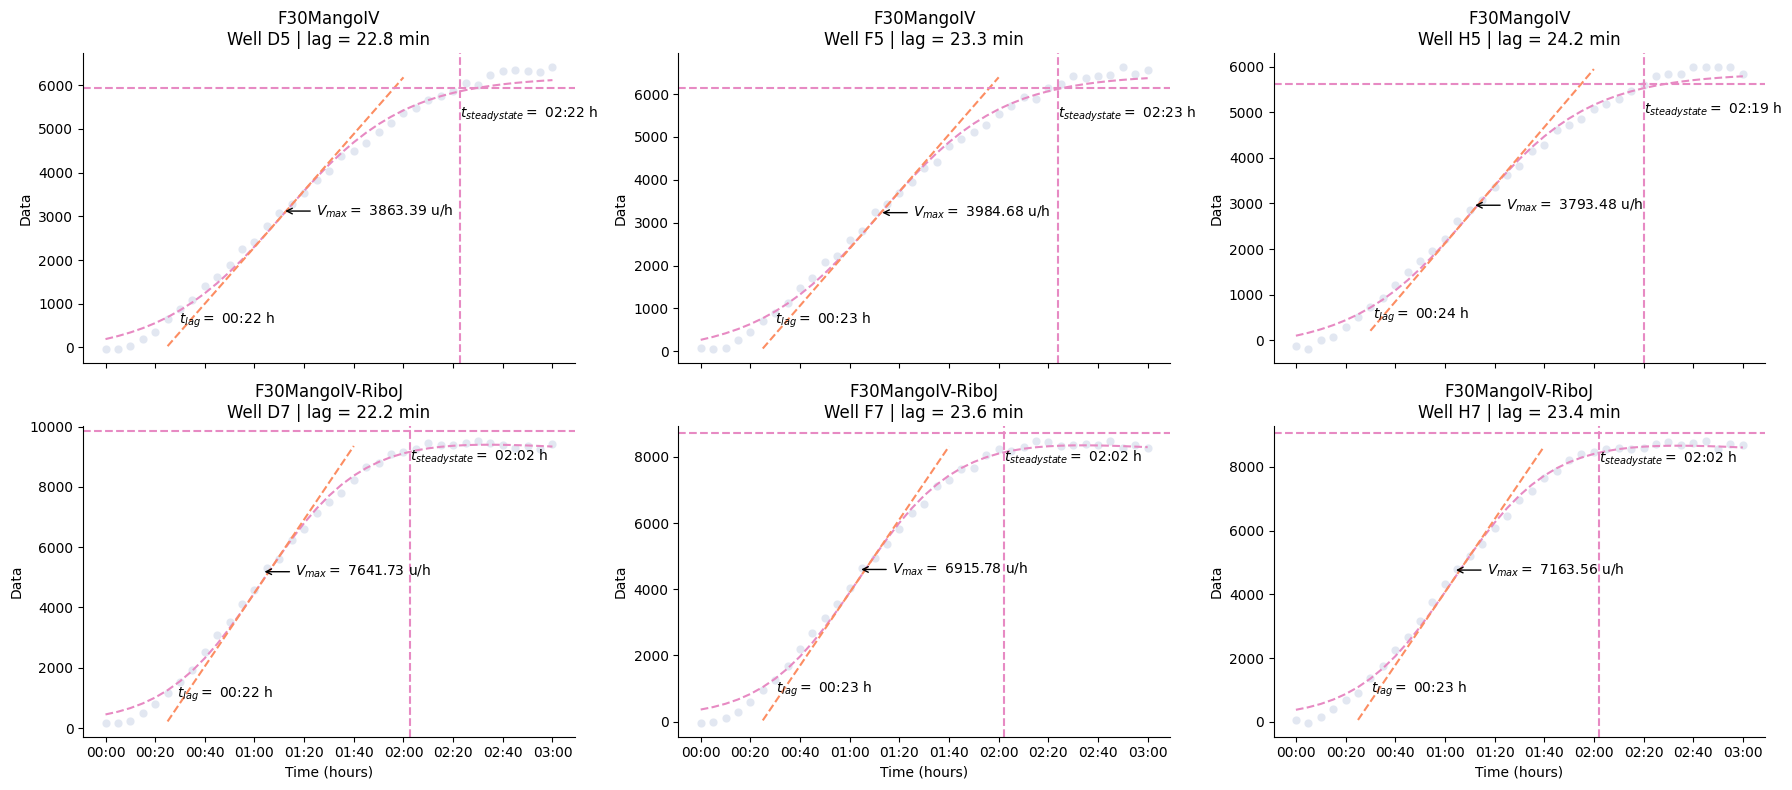

In [8]:
# F30MangoIV per-well TO1-Biotin kinetics
f30_mango_subset = data[
    (data["Name"].isin(["F30MangoIV-mScarlet", "F30MangoIV-RiboJ-mScarlet"])) &
    (data["Read"] == "TO1-Biotin") &
    (data["Time"] <= pd.Timedelta("3 hours"))
].copy()

well_order_f30 = ["D5", "F5", "H5", "D7", "F7", "H7"]
f30_mango_subset["Well"] = pd.Categorical(f30_mango_subset["Well"], categories=well_order_f30, ordered=True)
f30_mango_subset = f30_mango_subset.sort_values("Well")

g = sns.FacetGrid(f30_mango_subset, col="Well", col_wrap=3, sharey=False, height=4, aspect=1.5)
g.map_dataframe(pr.plot_kinetics_by_well, kinetics=per_well_TO1,
                group_by=["Name", "Read", "Well"], show_fit=True, annotate=True)

for ax in g.axes.flat:
    title = ax.get_title()
    well = title.split(" = ")[1].strip()
    name = f30_mango_subset[f30_mango_subset["Well"] == well]["Name"].iloc[0]
    lag = per_well_TO1.loc[(name, "TO1-Biotin", well), "Lag"]["Time"].total_seconds() / 60
    ax.set_title(f"{name.replace('-mScarlet', '')}\nWell {well} | lag = {lag:.1f} min")

plt.tight_layout()
plt.show()

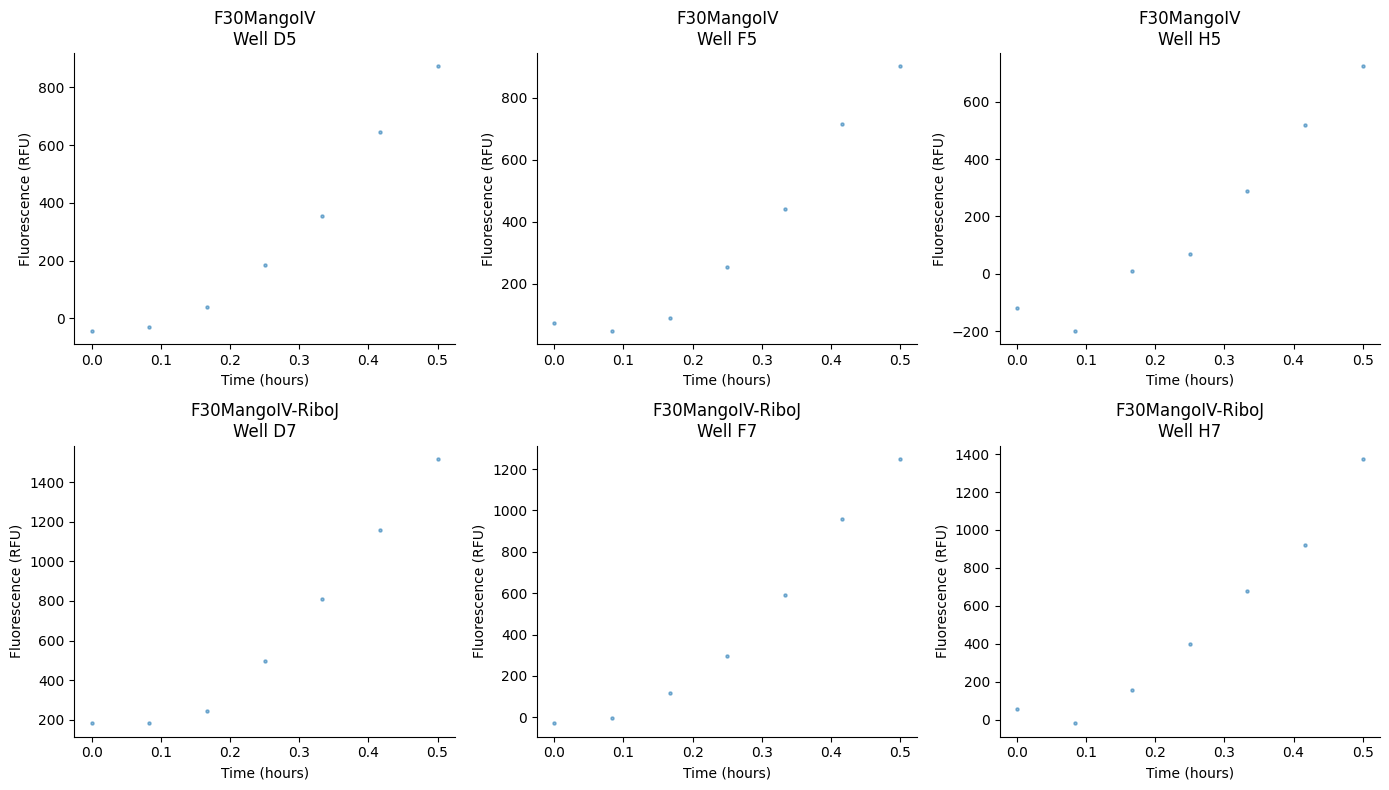

In [9]:
# First hour zoom to highlight early spike
f30_spike_subset = data[
    (data["Name"].isin(["F30MangoIV-mScarlet", "F30MangoIV-RiboJ-mScarlet"])) &
    (data["Read"] == "TO1-Biotin") &
    (data["Time"] <= pd.Timedelta("0.5 hour"))
].copy()

well_order_f30 = ["D5", "F5", "H5", "D7", "F7", "H7"]
f30_spike_subset["Well"] = pd.Categorical(f30_spike_subset["Well"], categories=well_order_f30, ordered=True)
f30_spike_subset = f30_spike_subset.sort_values("Well")

fig, axes = plt.subplots(2, 3, figsize=(14, 8), sharey=False)

for ax, (_, row) in zip(axes.flat, f30_spike_subset.groupby("Well", observed=True)):
    well = row["Well"].iloc[0]
    name = row["Name"].iloc[0]
    ax.scatter(row["Time (hours)"], row["Data"], s=5, alpha=0.5)
    ax.set_title(f"{name.replace('-mScarlet', '')}\nWell {well}")
    ax.set_xlabel("Time (hours)")
    ax.set_ylabel("Fluorescence (RFU)")

sns.despine()
plt.tight_layout()
plt.show()

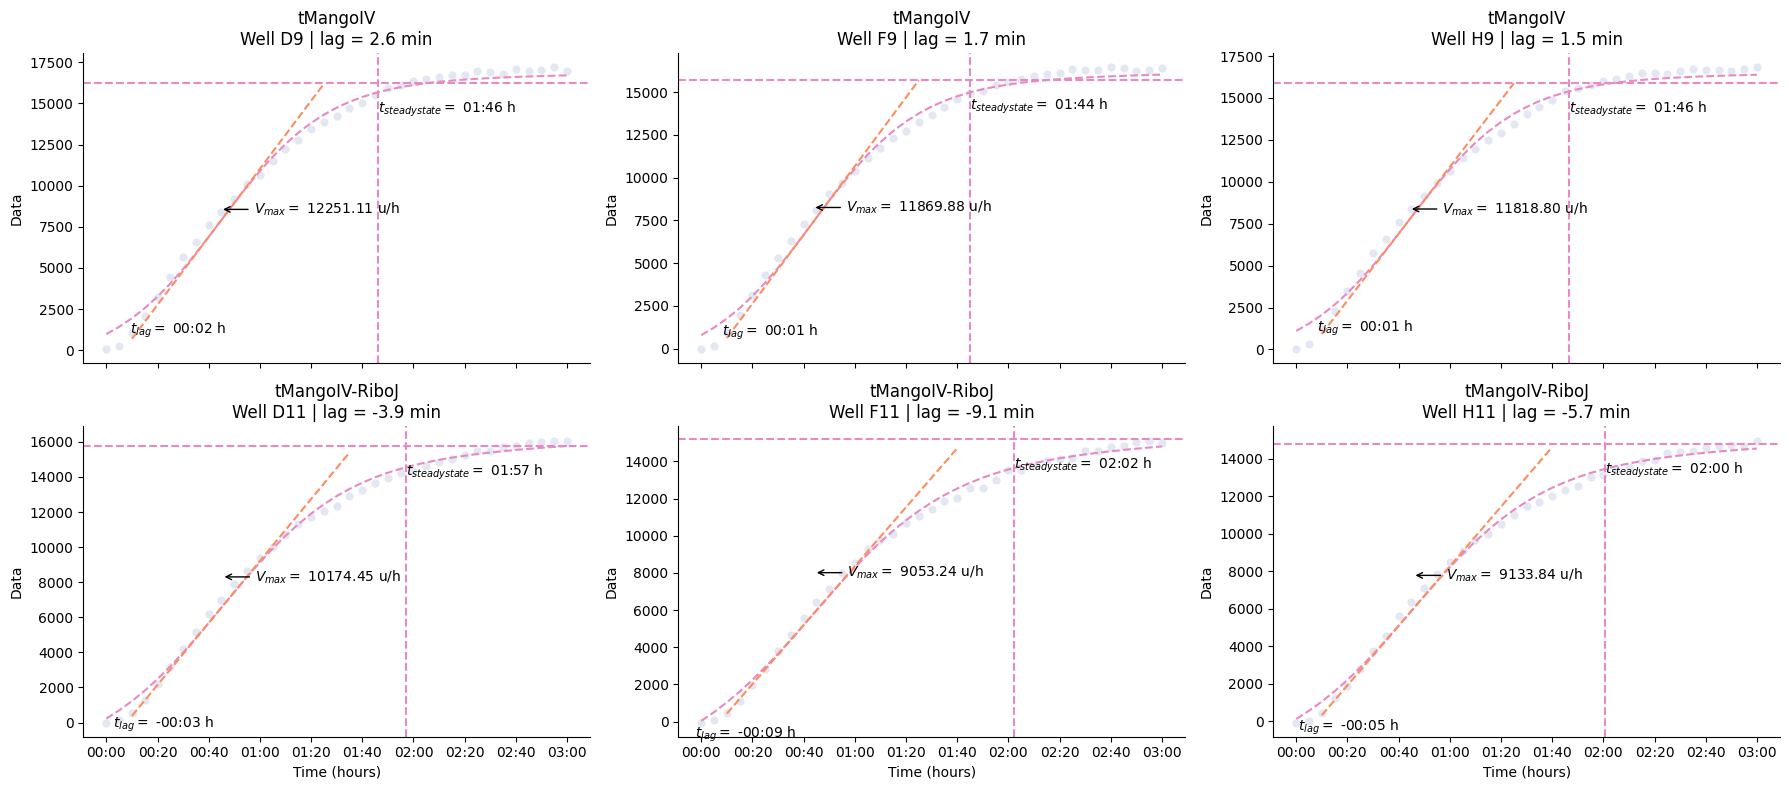

In [10]:
# tMangoIV per-well TO1-Biotin kinetics
tmango_subset = data[
    (data["Name"].isin(["tMangoIV-mScarlet", "tMangoIV-RiboJ-mScarlet"])) &
    (data["Read"] == "TO1-Biotin") &
    (data["Time"] <= pd.Timedelta("3 hours"))
].copy()

well_order_tmango = ["D9", "F9", "H9", "D11", "F11", "H11"]
tmango_subset["Well"] = pd.Categorical(tmango_subset["Well"], categories=well_order_tmango, ordered=True)
tmango_subset = tmango_subset.sort_values("Well")

g = sns.FacetGrid(tmango_subset, col="Well", col_wrap=3, sharey=False, height=4, aspect=1.5)
g.map_dataframe(pr.plot_kinetics_by_well, kinetics=per_well_TO1,
                group_by=["Name", "Read", "Well"], show_fit=True, annotate=True)

for ax in g.axes.flat:
    title = ax.get_title()
    well = title.split(" = ")[1].strip()
    name = tmango_subset[tmango_subset["Well"] == well]["Name"].iloc[0]
    lag = per_well_TO1.loc[(name, "TO1-Biotin", well), "Lag"]["Time"].total_seconds() / 60
    ax.set_title(f"{name.replace('-mScarlet', '')}\nWell {well} | lag = {lag:.1f} min")

plt.tight_layout()
#plt.savefig("./figures/tMangoIV_per_well_TO1_kinetics.png", dpi=600, bbox_inches="tight")
plt.show()